MultiFlag Model (NEXT STEP 🔥)

→ Predict: Type of denial

F → Fully denied
P → Partially denied
Z → Zero-pay
N → Not denied

“After predicting denial risk, I built a multi-class model to classify claims into Fully denied, Partially denied, Zero-pay, and Not denied. I handled class imbalance using class weights and evaluated using per-class F1 scores and confusion matrix. I also explored a hierarchical approach to improve performance.”

In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

from lightgbm import LGBMClassifier

import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df_raw = pd.read_csv("ClaimDenialInputMultiLabel.csv")

C:\Users\SreejaChiluveru\AppData\Local\Temp\ipykernel_21036\657942867.py:1: DtypeWarning: Columns (18,19) have mixed types. Specify dtype option on import or set low_memory=False.
  df_raw = pd.read_csv("ClaimDenialInputMultiLabel.csv")


In [4]:
print(df_raw.shape)
print(df_raw.columns)
print(df_raw.head())

(1000000, 39)
Index(['Clinic', 'TPCLIID', 'LIATPCLIid', 'ServiceDt', 'Service', 'ClaimID',
       'AmountCharged', 'CPTCode', 'ClientID', 'ClaimBillDate', 'Payer',
       'Provider', 'BillingProviderNPI', 'ClaimFacilityNPI', 'AuthStatus',
       'eligStatus', 'DenialFlag', 'lastActDt', 'cliANSI1', 'cliANSI2',
       'target1', 'target2', 'target3', 'target4', 'TotalPaid', 'TotalAdj',
       'TotalVoid', 'CoPay', 'Deduc', 'CoIns', 'CltResp', 'Balance',
       'MultiFlag', 'SameDayCli', 'DaysBetServiceToBilling',
       'tpcliStrModifier', 'tpcliStrPOS', 'f21diag1', 'f11insdob'],
      dtype='object')
         Clinic      TPCLIID    LIATPCLIid   ServiceDt  \
0  CLN_13838227  TP_41935074   LTP_1870199  2025-06-22   
1  CLN_13838227  TP_44604858  LTP_82010373  2025-06-29   
2  CLN_13838227  TP_26594858           NaN  2025-07-06   
3  CLN_13838227  TP_95683641   LTP_2144057  2025-07-13   
4  CLN_13838227  TP_90042682  LTP_38875939  2025-07-20   

                      Service    ClaimID  Am

In [5]:
df_raw

,Clinic,TPCLIID,LIATPCLIid,ServiceDt,Service,ClaimID,AmountCharged,CPTCode,ClientID,ClaimBillDate,...,CoIns,CltResp,Balance,MultiFlag,SameDayCli,DaysBetServiceToBilling,tpcliStrModifier,tpcliStrPOS,f21diag1,f11insdob
0,CLN_13838227,TP_41935074,LTP_1870199,2025-06-22,Methadone Maintenance Week,143008644,297.61,H0020,CLT_85822412,2025-04-06,...,0.0,0.0,0.00,N,0,1,NaN,11,F1120,NaN
1,CLN_13838227,TP_44604858,LTP_82010373,2025-06-29,Methadone Maintenance Week,143008720,208.74,H0020,CLT_85822412,2025-04-13,...,0.0,0.0,0.00,N,0,1,NaN,11,F1120,NaN
2,CLN_13838227,TP_26594858,NaN,2025-07-06,Methadone Maintenance Week,143009390,238.49,H0020,CLT_85822412,2025-06-03,...,0.0,0.0,224.01,NaN,0,45,NaN,11,F1120,NaN
3,CLN_13838227,TP_95683641,LTP_2144057,2025-07-13,Methadone Maintenance Week,143008875,245.26,H0020,CLT_85822412,2025-04-27,...,0.0,0.0,283.10,Z,0,1,NaN,11,F1120,NaN
4,CLN_13838227,TP_90042682,LTP_38875939,2025-07-20,Methadone Maintenance Week,143008961,228.32,H0020,CLT_85822412,2025-05-05,...,0.0,0.0,226.06,Z,0,2,NaN,11,F1120,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,CLN_20041488,TP_28231781,LTP_22240665,2025-10-19,Take Home Dose MMT,105186924,6.70,H0020,CLT_82150984,2025-04-27,...,0.0,0.0,0.00,N,0,2,NaN,11,F1120,NaN
999996,CLN_20041488,TP_14603567,LTP_86430893,2025-10-25,Take Home Dose MMT,105187299,8.68,H0020,CLT_82150984,2025-05-04,...,0.0,0.0,0.00,N,0,3,NaN,11,F1120,NaN
999997,CLN_20041488,TP_67501817,LTP_63741515,2025-10-26,Take Home Dose MMT,105187299,7.39,H0020,CLT_82150984,2025-05-04,...,0.0,0.0,0.00,N,0,2,NaN,11,F1120,NaN
999998,CLN_20041488,TP_83554380,LTP_50442122,2025-11-02,Take Home Dose MMT,105187791,8.79,H0020,CLT_82150984,2025-05-11,...,0.0,0.0,0.00,N,0,2,NaN,11,F1120,NaN


In [6]:
print(df_raw.isnull().sum())

Clinic                           0
TPCLIID                          0
LIATPCLIid                   73985
ServiceDt                        0
Service                          0
ClaimID                          0
AmountCharged                    0
CPTCode                          0
ClientID                         0
ClaimBillDate                    0
Payer                            0
Provider                        12
BillingProviderNPI               0
ClaimFacilityNPI                 0
AuthStatus                 1000000
eligStatus                  234760
DenialFlag                   73985
lastActDt                    73985
cliANSI1                    778408
cliANSI2                    980313
target1                     778410
target2                     965909
target3                     996126
target4                     999014
TotalPaid                        0
TotalAdj                         0
TotalVoid                        0
CoPay                            0
Deduc               

remove data lekeage columns

In [8]:
leakage_cols = [
    "DenialFlag",
    "TotalPaid",
    "TotalAdj",
    "TotalVoid",
    "Balance",
    "cliANSI1",
    "cliANSI2"
]

df_raw = df_raw.drop(columns=leakage_cols, errors="ignore")

In [9]:
df=df_raw.copy()


so now use df for other chnages 

In [10]:
target_cols = ["target1", "target2", "target3", "target4"]

In [12]:
drop_cols = [
    "AuthStatus",
    "f11insdob",
    "cliANSI2"
]

In [13]:
cols_to_drop = drop_cols+ target_cols

df = df.drop(columns=cols_to_drop, errors="ignore")

handling missing values

In [14]:
df["eligStatus"] = df["eligStatus"].fillna("Unknown")

In [15]:
df=df.copy()

till now all chnages needed for all the other splitting techniques and other modles testing

In [20]:
print(df.isnull().sum())

Clinic                         0
ServiceDt                      0
Service                        0
AmountCharged                  0
CPTCode                        0
ClaimBillDate                  0
Payer                          0
Provider                      12
BillingProviderNPI             0
ClaimFacilityNPI               0
eligStatus                     0
CoPay                          0
Deduc                          0
CoIns                          0
CltResp                        0
MultiFlag                  73985
SameDayCli                     0
DaysBetServiceToBilling        0
tpcliStrPOS                    0
f21diag1                       0
dtype: int64


In [21]:
df = df.drop(columns=["tpcliStrModifier"], errors="ignore")

In [22]:
df = df.drop(columns=["lastActDt"], errors="ignore")

In [23]:
id_cols = [
    "ClaimID",
    "ClientID",
    "TPCLIID",
    "LIATPCLIid"
]

df = df.drop(columns=id_cols, errors="ignore")

filling it as there are less missing values

In [24]:
df["Provider"] = df["Provider"].fillna("Unknown")

In [25]:
print(df.isnull().sum())

Clinic                         0
ServiceDt                      0
Service                        0
AmountCharged                  0
CPTCode                        0
ClaimBillDate                  0
Payer                          0
Provider                       0
BillingProviderNPI             0
ClaimFacilityNPI               0
eligStatus                     0
CoPay                          0
Deduc                          0
CoIns                          0
CltResp                        0
MultiFlag                  73985
SameDayCli                     0
DaysBetServiceToBilling        0
tpcliStrPOS                    0
f21diag1                       0
dtype: int64


AS THERE ARE MANY MISSING VALUES IN TARGET COLUMN ONLY,SO REMOVING THE ROWS WHICH ARE ARE MISSING IN TARGET COLUMN

In [26]:
df = df.dropna(subset=["MultiFlag"])

In [27]:
print(df.isnull().sum())

Clinic                     0
ServiceDt                  0
Service                    0
AmountCharged              0
CPTCode                    0
ClaimBillDate              0
Payer                      0
Provider                   0
BillingProviderNPI         0
ClaimFacilityNPI           0
eligStatus                 0
CoPay                      0
Deduc                      0
CoIns                      0
CltResp                    0
MultiFlag                  0
SameDayCli                 0
DaysBetServiceToBilling    0
tpcliStrPOS                0
f21diag1                   0
dtype: int64


In [30]:
df.dtypes

Clinic                      object
ServiceDt                   object
Service                     object
AmountCharged              float64
CPTCode                     object
ClaimBillDate               object
Payer                       object
Provider                    object
BillingProviderNPI          object
ClaimFacilityNPI            object
eligStatus                  object
CoPay                      float64
Deduc                      float64
CoIns                      float64
CltResp                    float64
MultiFlag                   object
SameDayCli                   int64
DaysBetServiceToBilling      int64
tpcliStrPOS                  int64
f21diag1                    object
dtype: object

==============================EDA=======================

1.TARGET DISTRIBUTION

In [31]:
df["MultiFlag"].value_counts(normalize=True)

MultiFlag
N    0.825651
P    0.105567
Z    0.052857
F    0.015925
Name: proportion, dtype: float64

HIGHLY IMBALANCED

Especially:

F (Fully denied) = only 1.5%
This is the hardest class

Evaluation Strategy (CHANGE THIS)

 Don’t rely on accuracy
 Use:

classification_report
macro F1
per-class recall

👉 Especially check:

Recall for F
Recall for Z

<Axes: xlabel='MultiFlag', ylabel='count'>

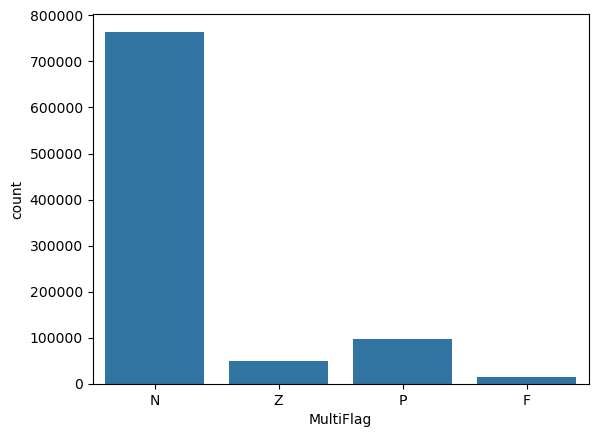

In [32]:
import seaborn as sns
sns.countplot(x="MultiFlag", data=df)

NUMERICAL FEATURE ANALYSIS

In [33]:
df.describe()

,AmountCharged,CoPay,Deduc,CoIns,CltResp,SameDayCli,DaysBetServiceToBilling,tpcliStrPOS
count,926015.000000,926015.000000,926015.000000,926015.000000,926015.000000,926015.000000,926015.000000,926015.000000
mean,49.778224,0.485587,0.534398,0.433027,0.473108,0.025179,8.453985,23.374585
std,74.881418,4.442882,9.722955,4.037217,7.620145,0.169067,29.267326,24.652545
min,0.040000,-94.060000,-253.480000,-344.140000,-394.430000,0.000000,-6.000000,10.000000
25%,7.250000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,11.000000
50%,13.270000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,11.000000
75%,68.640000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,11.000000
max,2219.210000,157.820000,1014.230000,595.360000,725.380000,9.000000,641.000000,87.000000


FEW FINANCIAL VALUES ARE IN NEGATIVE SO COVERTING IT TO 0

In [35]:
for col in ["CoPay", "Deduc", "CoIns", "CltResp"]:
    df[col] = df[col].clip(lower=0)

DaysBetServiceToBilling → OUTLIERS
Mean = 8
Max = 641 ❌
Min = -6 ❌
🚨 Problems:
Negative days → impossible
Very high values → extreme delays

In [36]:
df["DaysBetServiceToBilling"] = df["DaysBetServiceToBilling"].clip(lower=0, upper=60)

Model learns:

Whether duplication exists
AND how severe it is

FEATURE ENGINEERING

In [37]:
df["SameDayCli_bin"] = (df["SameDayCli"] > 0).astype(int)

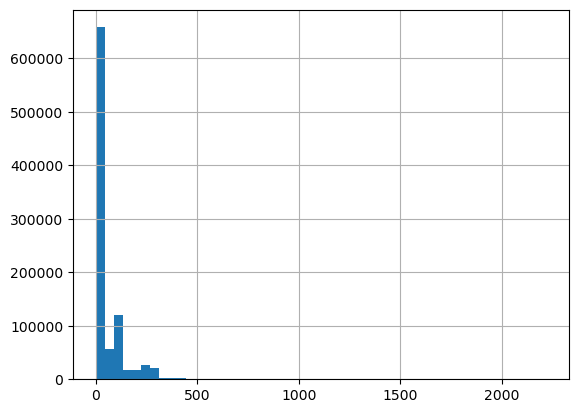

In [38]:
import matplotlib.pyplot as plt

df["AmountCharged"].hist(bins=50)
plt.show()

In [39]:
pd.crosstab(df["Payer"], df["MultiFlag"], normalize="index")

MultiFlag,F,N,P,Z
Payer,,,,
PAY_10657547,0.000000,1.000000,0.000000,0.000000
PAY_11766833,0.000000,0.000000,0.000000,1.000000
PAY_11771255,0.013514,0.000000,0.954955,0.031532
PAY_12499198,0.000000,0.980198,0.000000,0.019802
PAY_14614652,0.012048,0.927711,0.012048,0.048193
...,...,...,...,...
PAY_97183585,0.000000,0.000000,1.000000,0.000000
PAY_97226871,0.020675,0.014146,0.936888,0.028292
PAY_97942503,0.000000,1.000000,0.000000,0.000000


In [42]:
pd.crosstab(df["Service"], df["MultiFlag"], normalize="index")
#pd.crosstab(df["eligStatus"], df["MultiFlag"], normalize="index")

MultiFlag,F,N,P,Z
Service,,,,
Admission Assessment,0.028846,0.416667,0.387821,0.166667
BAC,0.366530,0.248248,0.000876,0.384346
Buprenorphine 2mg,0.000000,1.000000,0.000000,0.000000
Buprenorphine 8mg,0.000000,1.000000,0.000000,0.000000
Buprenorphine Induction,0.000000,1.000000,0.000000,0.000000
...,...,...,...,...
Toxicology,0.100467,0.890966,0.000000,0.008567
Treatment Plan Review,0.000000,0.886243,0.000000,0.113757
UDS Review,0.002508,0.920376,0.000000,0.077116


In [41]:
pd.crosstab(df["eligStatus"], df["MultiFlag"], normalize="index")

MultiFlag,F,N,P,Z
eligStatus,,,,
Not Verified,0.008327,0.830718,0.112159,0.048796
Unknown,0.039164,0.811701,0.083819,0.065315
Verified,0.006897,0.560920,0.390805,0.041379


<Axes: >

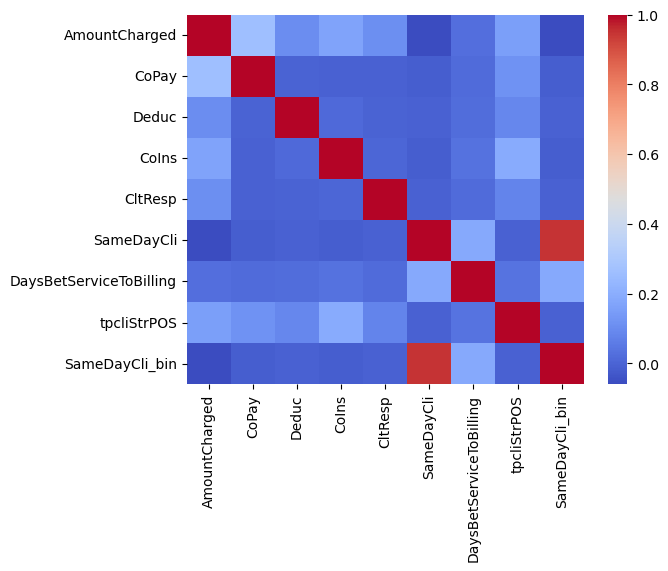

In [43]:
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm")

<Axes: xlabel='MultiFlag', ylabel='AmountCharged'>

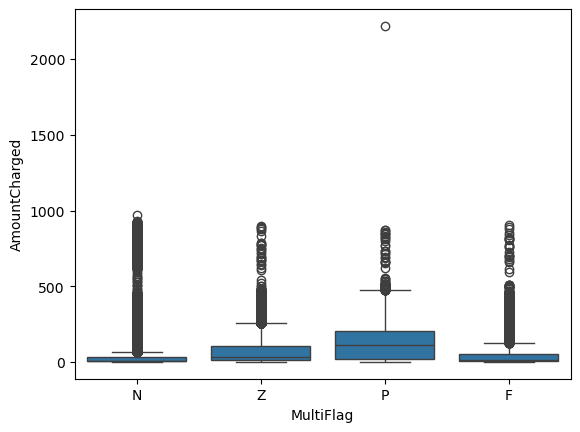

In [44]:
sns.boxplot(x="MultiFlag", y="AmountCharged", data=df)

log transfrom

FEATURE ENGINN

In [45]:
df["AmountCharged_log"] = np.log1p(df["AmountCharged"])
df = df.drop(columns=["AmountCharged"])

PAYER vs MULTIFLAG EDA:
Some payers → 100% N
Some → high P or Z

INSIGHT:Payer is a VERY STRONG feature
 Problem:High cardinality (~200+ payers)
One-hot encoding =  BAD (overfitting)
Solution:

Use frequency encoding:High cardinality features (many unique categories like IDs, cities, products)
Frequency encoding = replace each category with how often it appears in the dataset.

to reduce correlation

In [46]:
df = df.drop(columns=["SameDayCli"])

CONVERTING DATES

In [47]:
df["ServiceDt"] = pd.to_datetime(df["ServiceDt"])
df["ClaimBillDate"] = pd.to_datetime(df["ClaimBillDate"])

NEW FEATURES ADDED

In [53]:
df["service_month"] = df["ServiceDt"].dt.month
df["service_day"] = df["ServiceDt"].dt.dayofweek



In [54]:
df["billing_delay"] = (df["ClaimBillDate"] - df["ServiceDt"]).dt.days
df["billing_delay"] = df["billing_delay"].abs()

In [55]:

df["charge_to_delay_ratio"] = df["AmountCharged_log"] / (df["billing_delay"] + 1)

Financial Ratios
Why:

High burden → likely Z or P

In [56]:
df["total_patient_burden"] = df["CoPay"] + df["Deduc"] + df["CoIns"]

In [57]:
df.head()

,Clinic,ServiceDt,Service,CPTCode,ClaimBillDate,Payer,Provider,BillingProviderNPI,ClaimFacilityNPI,eligStatus,...,DaysBetServiceToBilling,tpcliStrPOS,f21diag1,SameDayCli_bin,AmountCharged_log,service_month,service_day,billing_delay,total_patient_burden,charge_to_delay_ratio
0,CLN_13838227,2025-06-22,Methadone Maintenance Week,H0020,2025-04-06,PAY_21461370,PRV_75825317,NPI_21138757,FAC_72555030,Not Verified,...,1,11,F1120,0,5.699138,6,6,77,0.0,0.073066
1,CLN_13838227,2025-06-29,Methadone Maintenance Week,H0020,2025-04-13,PAY_21461370,PRV_75825317,NPI_21138757,FAC_72555030,Not Verified,...,1,11,F1120,0,5.345869,6,6,77,0.0,0.068537
3,CLN_13838227,2025-07-13,Methadone Maintenance Week,H0020,2025-04-27,PAY_21461370,PRV_97303041,NPI_21138757,FAC_72555030,Not Verified,...,1,11,F1120,0,5.506388,7,6,77,0.0,0.070595
4,CLN_13838227,2025-07-20,Methadone Maintenance Week,H0020,2025-05-05,PAY_21461370,PRV_97303041,NPI_21138757,FAC_72555030,Not Verified,...,2,11,F1120,0,5.435118,7,6,76,0.0,0.070586
5,CLN_13838227,2025-07-27,Methadone Maintenance Week,H0020,2025-05-12,PAY_21461370,PRV_97303041,NPI_21138757,FAC_72555030,Not Verified,...,2,11,F1120,0,5.594972,7,6,76,0.0,0.072662


In [58]:
df["total_patient_burden"].describe()

count    926015.000000
mean          1.465203
std          11.382108
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max        1014.230000
Name: total_patient_burden, dtype: float64

75% of values = 0

👉 Only ~25% have non-zero values

👉 Very highly skewed feature

This feature is actually very powerful

Why?

🧠 Business Meaning

total_patient_burden = CoPay + Deduc + CoIns

💡 What zero means:
Patient has NO financial responsibility
➡️ Likely N (approved)
💡 What non-zero means:
Patient pays something
➡️ Likely:
Z (zero pay)
P (partial)
🔥 So this feature is:

👉 Sparse but VERY informative

⚠️ But there is a problem

👉 Model may struggle because:

Mostly zeros
Few large values
✅ BEST PRACTICE (DO THIS)
👉 Create binary feature

This adds:

binary signal → whether patient has any financial burden
Helps separate:
N (often 0 burden)
P/Z (non-zero burden

In [59]:
df["has_patient_burden"] = (df["total_patient_burden"] > 0).astype(int)

Important Rule:

👉 Anything that learns from data distribution must be done AFTER split

after encoding it uses full dataset info

If done before split:



 Validation data leaks into training
 Model becomes over-optimistic

In [134]:
df["is_high_patient_pay"] = (df["total_patient_burden"] > 0).astype(int)

df["patient_pay_ratio"] = df["total_patient_burden"] / (df["AmountCharged_log"] + 1)

In [155]:
df["burden_vs_charge"] = df["total_patient_burden"] / (df["AmountCharged_log"] + 1)
df["likely_zero_pay"] = (df["burden_vs_charge"] > 0.8).astype(int)

In [156]:
df_main=df.copy()

THIS IS THE MAIN DF CAN USE FOR MULTIPLE MODELS AND SPILTS

TEMPORAL SPLITTING---------------------------------------------------------------------------------------------------


In [157]:
df_temp= df_main.copy()

In [158]:
# # Sort by time
# df = df.sort_values(by="ServiceDt")

# # 80% time split
# split_date = df["ServiceDt"].quantile(0.8)

# train_df = df[df["ServiceDt"] <= split_date].copy()
# val_df   = df[df["ServiceDt"] > split_date].copy()

# print(train_df.shape, val_df.shape)

df_temp = df_temp.sort_values(by="ServiceDt")

split_date = df_temp["ServiceDt"].quantile(0.8)

train_df = df_temp[df_temp["ServiceDt"] <= split_date].copy()
val_df   = df_temp[df_temp["ServiceDt"] > split_date].copy()

USE DF_TEMP FOR TEMPORAL SPLITTING-----------------------------

FREQUENCY ENCODING

In [159]:
high_card_cols = ["Clinic", "Payer", "Provider", "CPTCode","Service", "BillingProviderNPI", "ClaimFacilityNPI"]

for col in high_card_cols:
    freq = train_df[col].value_counts(normalize=True)

    train_df[col] = train_df[col].map(freq)
    val_df[col]   = val_df[col].map(freq)

    # handle unseen categories in val
    val_df[col] = val_df[col].fillna(0)

ENCODING

In [160]:
cat_cols = ["eligStatus", "tpcliStrPOS", "f21diag1"]

for col in cat_cols:
    train_df[col] = train_df[col].astype("category")
    val_df[col]   = val_df[col].astype("category")

DROP DATE COLUMNS BEFORE TRAINING

In [161]:
train_df = train_df.drop(columns=["ServiceDt", "ClaimBillDate"], errors="ignore")
val_df   = val_df.drop(columns=["ServiceDt", "ClaimBillDate"], errors="ignore")

In [162]:
# X_train = train_df.drop(columns=["MultiFlag"])
# y_train = train_df["MultiFlag"]

# X_val = val_df.drop(columns=["MultiFlag"])
# y_val = val_df["MultiFlag"]'ArithmeticError


X_train = train_df.drop(columns=["MultiFlag"])
X_val   = val_df.drop(columns=["MultiFlag"])

In [163]:
from sklearn.preprocessing import LabelEncoder

# get original labels (IMPORTANT)
y_train = train_df["MultiFlag"]
y_val   = val_df["MultiFlag"]

# encode
# le = LabelEncoder()
# y_train = le.fit_transform(y_train)
# y_val   = le.transform(y_val)

In [164]:
from lightgbm import LGBMClassifier

class_weights = {
    'F': 5,
    'N': 1,
    'P': 2,
    'Z': 7
}

model = LGBMClassifier(
    objective="multiclass",
    num_class=4,
    n_estimators=400,
    learning_rate=0.05,
    max_depth=8,
    min_child_samples=30,
    subsample=0.8,
    colsample_bytree=0.8,
    class_weight=class_weights,
    random_state=42
)

ENCODING TARGET----------------------

In [165]:
model.fit(X_train,y_train)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.018777 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3120
[LightGBM] [Info] Number of data points in the train set: 743292, number of used features: 26
[LightGBM] [Info] Start training from score -2.761785
[LightGBM] [Info] Start training from score -0.573153
[LightGBM] [Info] Start training from score -2.028309
[LightGBM] [Info] Start training from score -1.420810
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,8
,learning_rate,0.05
,n_estimators,400
,subsample_for_bin,200000
,objective,'multiclass'
,class_weight,"{'F': 5, 'N': 1, 'P': 2, 'Z': 7}"
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,30


In [166]:
print(train_df["MultiFlag"].unique())

['Z' 'F' 'N' 'P']


In [167]:
print(type(y_train[0]))

<class 'str'>


In [168]:
from sklearn.metrics import classification_report

y_pred = model.predict(X_val)

print(classification_report(y_val, y_pred))

              precision    recall  f1-score   support

           F       0.35      0.50      0.41       867
           N       0.96      0.95      0.96    145309
           P       0.82      0.80      0.81     25501
           Z       0.33      0.36      0.34     11046

    accuracy                           0.90    182723
   macro avg       0.61      0.65      0.63    182723
weighted avg       0.90      0.90      0.90    182723



In [169]:
probs = model.predict_proba(X_val)
print(probs.shape)

(182723, 4)


In [170]:
print(le.classes_)

['F' 'N' 'P' 'Z']


In [171]:
z_index = list(le.classes_).index('Z')

In [174]:
import numpy as np

threshold = 0.30   # try 0.25–0.40

y_pred_custom = []

for p in probs:
    if p[z_index] > threshold:
        y_pred_custom.append(z_index)
    else:
        y_pred_custom.append(np.argmax(p))

y_pred_custom = np.array(y_pred_custom)
y_pred_custom = le.inverse_transform(y_pred_custom)

In [175]:
from sklearn.metrics import classification_report

print(classification_report(y_val, y_pred_custom))

              precision    recall  f1-score   support

           F       0.36      0.46      0.40       867
           N       0.96      0.93      0.95    145309
           P       0.82      0.77      0.80     25501
           Z       0.27      0.43      0.33     11046

    accuracy                           0.87    182723
   macro avg       0.60      0.65      0.62    182723
weighted avg       0.90      0.87      0.89    182723



threshold 3

In [178]:
thrsshodl 3

SyntaxError: invalid syntax (444129527.py, line 1)

In [176]:
import numpy as np

threshold = 0.35   # try 0.25–0.40

y_pred_custom = []

for p in probs:
    if p[z_index] > threshold:
        y_pred_custom.append(z_index)
    else:
        y_pred_custom.append(np.argmax(p))

y_pred_custom = np.array(y_pred_custom)
y_pred_custom = le.inverse_transform(y_pred_custom)

threshold 35

In [177]:
from sklearn.metrics import classification_report

print(classification_report(y_val, y_pred_custom))

              precision    recall  f1-score   support

           F       0.35      0.48      0.41       867
           N       0.96      0.94      0.95    145309
           P       0.82      0.78      0.80     25501
           Z       0.29      0.40      0.34     11046

    accuracy                           0.88    182723
   macro avg       0.61      0.65      0.62    182723
weighted avg       0.90      0.88      0.89    182723



In [148]:
print(df.columns)

Index(['Clinic', 'ServiceDt', 'Service', 'CPTCode', 'ClaimBillDate', 'Payer',
       'Provider', 'BillingProviderNPI', 'ClaimFacilityNPI', 'eligStatus',
       'CoPay', 'Deduc', 'CoIns', 'CltResp', 'MultiFlag',
       'DaysBetServiceToBilling', 'tpcliStrPOS', 'f21diag1', 'SameDayCli_bin',
       'AmountCharged_log', 'service_month', 'service_day', 'billing_delay',
       'total_patient_burden', 'charge_to_delay_ratio', 'has_patient_burden',
       'is_high_patient_pay', 'patient_pay_ratio'],
      dtype='object')
